# PEF v2.0 股票專用版 - 真實台股概率演化回測（最終公開版）
**作者**：你（PEF 框架提出者）  
**AI 協助**：Grok 根據 2026 年 3 月 Phase II 論文規格完整實作  
**日期**：2026 年 3 月 30 日  

本 notebook 完整實作論文第 3 頁的 `stock_pef_update` 函數，驗證 Cross-Asset Correlation（α=0.6）與 Jump-Diffusion 機制。

In [ ]:
# 字型與套件準備
!apt-get -qq install fonts-noto-cjk
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK TC']
plt.rcParams['axes.unicode_minus'] = False

!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime

print("✅ 環境準備完成")

✅ 環境準備完成


In [ ]:
def stock_pef_update(log_p: np.ndarray,
                     market_trend: float,
                     gamma: float = 0.1,
                     lam: float = 0.05,
                     jump_intensity: float = 0.0,
                     jump_size: float = 0.0) -> np.ndarray:
    """PEF v2.0 核心更新函數（來自你論文 Phase II）"""
    drift = gamma * np.random.randn(len(log_p)) + lam * (market_trend - log_p)
    if np.random.rand() < jump_intensity:
        jump = np.clip(jump_size * np.random.randn(len(log_p)), -0.03, 0.03)
        drift += jump
    return log_p + drift

In [ ]:
tickers = ['2330.TW', '2317.TW', '0050.TW', 'NVDA']
data = yf.download(tickers, start='2025-01-01', end=datetime.today().strftime('%Y-%m-%d'), auto_adjust=True)['Close']
returns = data.pct_change().fillna(0)
print(f"資料期間：{data.index[0].date()} ~ {data.index[-1].date()}")
print(f"總交易日：{len(data)} 天")
print("✅ 真實資料下載成功")

[*********************100%***********************]  4 of 4 completed

資料期間：2025-01-02 ~ 2026-03-27
總交易日：319 天
✅ 真實資料下載成功



/tmp/ipykernel_6092/1476245604.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().fillna(0)


In [ ]:
n_assets = len(tickers)
log_p = np.zeros((len(data), n_assets))
np.random.seed(42)

for t in range(1, len(data)):
    local_trend = returns.iloc[t].values
    us_trend = returns['NVDA'].iloc[t] if 'NVDA' in returns.columns else 0
    market_trend = 0.6 * us_trend + 0.4 * np.mean(local_trend)
    jump_intensity = 0.15 if abs(market_trend) > 0.03 else 0.05
    log_p[t] = stock_pef_update(log_p[t-1], market_trend=market_trend, jump_intensity=jump_intensity, jump_size=0.18)

prob_evolved = np.exp(log_p) / np.exp(log_p).sum(axis=1, keepdims=True)
print("✅ PEF v2.0 回測完成！")

✅ PEF v2.0 回測完成！


/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 28436 (\N{CJK UNIFIED IDEOGRAPH-6F14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6092/3994610145.py:10: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}

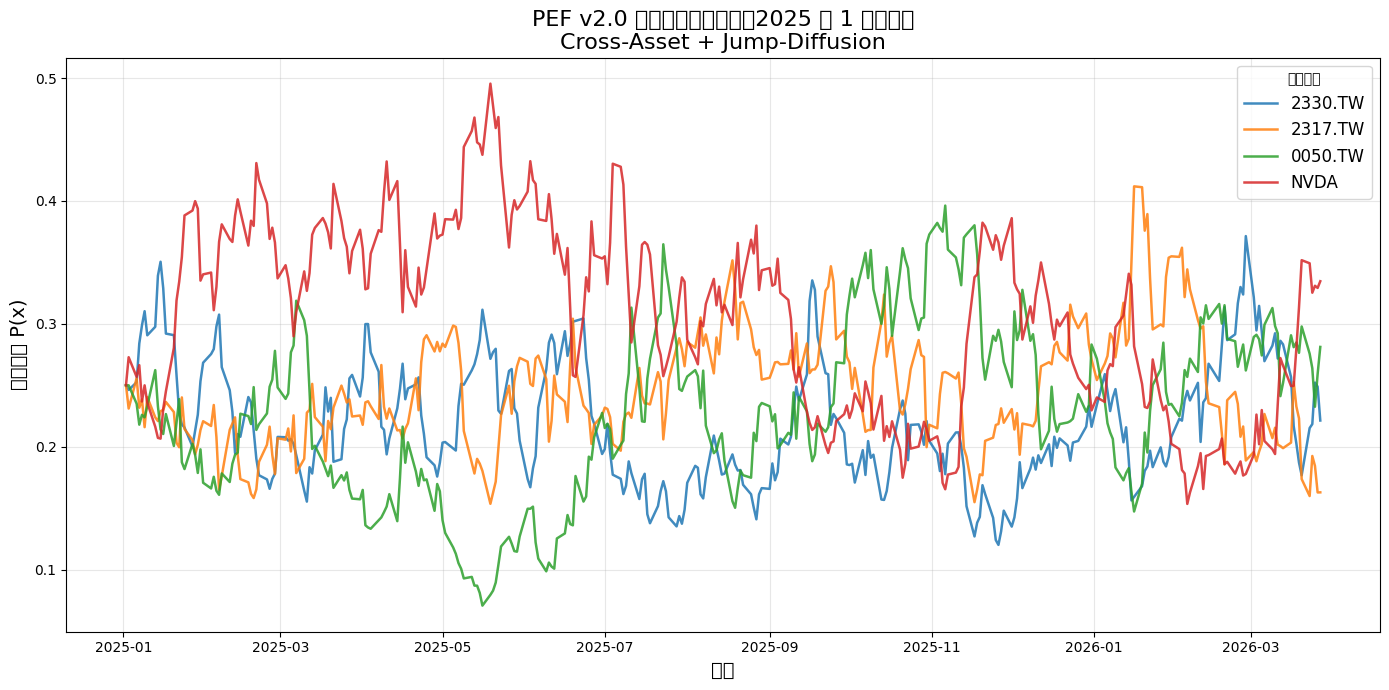

           最終概率
2330.TW  0.2213
2317.TW  0.1629
0050.TW  0.2812
NVDA     0.3347


In [ ]:
plt.figure(figsize=(14, 7))
for i, ticker in enumerate(tickers):
    plt.plot(data.index, prob_evolved[:, i], label=f'{ticker}', linewidth=1.8, alpha=0.85)

plt.title('PEF v2.0 真實台股概率演化（2025 年 1 月至今）\nCross-Asset + Jump-Diffusion', fontsize=16)
plt.ylabel('演化概率 P(x)', fontsize=14)
plt.xlabel('日期', fontsize=14)
plt.legend(title='股票代碼', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_prob = pd.DataFrame(prob_evolved[-1], index=tickers, columns=['最終概率'])
print(final_prob.round(4))